# Phase 4: Data Collection and Exploratory Data Analysis
**CS 5304 | Spring 2026**

**Team Members:**
- Hongyiming Cui
- Xiaohui Zang
- Jiawei Wang
- George Zhu

## GitHub Repository Link: 

https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project

## Research Question

**Primary question:** To what extent does the socioeconomic gradient — measured by state-level median household income — explain variation in chronic disease mortality (heart disease and diabetes) across U.S. states in 2024?

**Secondary question:** How much of the income–mortality relationship is mediated by health behaviors (obesity, smoking, physical inactivity), versus income acting as an independent predictor?

We focus on state-level cross-sectional data for 2024 because our datasets lack monthly granularity, making a cross-sectional design more appropriate than a short panel. The unit of analysis is the U.S. state (+ D.C.), giving us 51 observations.

***
## Data Description

We construct a **cross-sectional dataset of U.S. states (50 states + D.C., n = 51) for 2024** to study how socioeconomic factors relate to chronic disease outcomes. The dataset combines publicly available sources and is merged into a single file:  `final_state_health_dataset_2024.csv`

### Data Sources

We use two primary data sources:

- **U.S. Census Bureau (ACS 2024 1-Year Estimates)**  

  - Provides median household income, our main socioeconomic variable.

- **Kaiser Family Foundation (KFF) State Health Facts (2024)**  

  - Provides state-level health outcomes and behavioral risk factors.

Raw data and full documentation are available at:  

- **GitHub repository:** [Phase 2 notebook](https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project/blob/main/Phase_2.ipynb). 

- **Raw datasets:** [Google Drive Folder (All Datasets)](https://drive.google.com/drive/folders/1NwQ0BWzhuBbGxfQMNevCeiuQg0POtBLS?usp=sharing)

### Unit of Analysis

- **Observation level:** U.S. state (including D.C.)  

- **Sample size:** 51  

- **Design:** Cross-sectional (2024 only)

A cross-sectional design is appropriate because the datasets do not provide consistent multi-period panel data at the state level.

### Key Variables

We focus on variables that capture the **socioeconomic gradient, health outcomes, and behavioral mechanisms**:

#### 1. Independent Variable (Socioeconomic)

- **Median_Income**: Median household income (USD)

#### 2. Dependent Variables (Health Outcomes)

- **Heart_Disease**: Death rate per 100,000 population  

- **Diabetes**: Death rate per 100,000 population  

#### 3. Behavioral and Health Controls

- **Obesity**: Proportion of adults with BMI ≥ 30  

- **Smoking**: Proportion of adults who smoke  

- **Physical_Activity**: Proportion meeting activity guidelines  

- **Diabetes_Prevalence**: Proportion diagnosed with diabetes  

- **Poor_Health**: Proportion reporting poor/fair health  

- **Uninsured_Adults**: Proportion of uninsured adults (ages 19–64)

### Why These Variables Matter

- **Income** serves as our primary measure of the socioeconomic gradient.  

- **Mortality variables** capture severe health outcomes tied to chronic disease.  

- **Behavioral variables** (e.g., smoking, obesity) allow us to test whether income affects health **indirectly through lifestyle factors**.  

- **Insurance and self-reported health** provide additional context and potential confounders.

### Notes

- Mortality variables are measured **per 100,000 population**, while behavioral variables are **proportions (0–1)**.  

- The dataset is designed to support regression-based analysis of the relationship between income, health behaviors, and mortality outcomes.

***
## Data Collection & Cleaning

All datasets were collected from publicly available sources, including the U.S. Census Bureau (ACS 2024) and KFF State Health Facts (2024). Because the raw files were not consistently structured, we applied a standardized cleaning pipeline. Most KFF datasets followed a similar format and were cleaned by removing metadata rows, selecting relevant columns, filtering to the 50 states plus D.C., and converting values to numeric format. The income dataset required additional preprocessing because it was stored in a wide format (states as columns); we reshaped it into a two-column format (State, Median_Income) before merging.

All datasets were merged using an inner join on state names to ensure consistency across variables. After merging, we identified a small number of missing values (all from Tennessee) due to data suppression in survey-based estimates. Because the dataset contains only 51 observations, we imputed these missing values using column means to preserve the full sample. The final cleaned dataset contains 51 observations and 10 variables, with no remaining missing values, and is used for all subsequent analyses.

The full data collection and cleaning process is documented in our  [Phase 2 notebook](https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project/blob/main/Phase_2.ipynb).

In [68]:
import pandas as pd

In [69]:
# Load final cleaned dataset produced by our data-cleaning notebook
df = pd.read_csv("final_state_health_dataset_2024.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (51, 10)


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


In [70]:
# Verify final dataset quality
print("Missing values:")
print(df.isna().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
State                  0
Median_Income          0
Diabetes               0
Diabetes_Prevalence    0
Poor_Health            0
Heart_Disease          0
Obesity                0
Physical_Activity      0
Smoking                0
Uninsured_Adults       0
dtype: int64

Data types:
State                   object
Median_Income            int64
Diabetes               float64
Diabetes_Prevalence    float64
Poor_Health            float64
Heart_Disease          float64
Obesity                float64
Physical_Activity      float64
Smoking                float64
Uninsured_Adults       float64
dtype: object


In [71]:
# Quick summary of variables used in analysis
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Median_Income,51.0,81467.706,12905.034,59127.000,72369.500,77871.000,89812.000,109707.000
Diabetes,51.0,22.182,4.409,13.700,19.500,22.500,24.000,34.300
Diabetes_Prevalence,51.0,0.121,0.021,0.084,0.106,0.120,0.132,0.184
Poor_Health,51.0,0.045,0.010,0.026,0.036,0.045,0.050,0.071
Heart_Disease,51.0,162.875,31.277,116.300,142.800,156.200,177.400,254.300
Obesity,51.0,0.338,0.038,0.249,0.312,0.342,0.368,0.414
Physical_Activity,51.0,0.779,0.035,0.694,0.764,0.782,0.796,0.861
Smoking,51.0,0.117,0.028,0.057,0.099,0.117,0.136,0.208
Uninsured_Adults,51.0,0.836,0.037,0.764,0.812,0.834,0.861,0.911


***
## Preregistration Statement

- **Hypothesis 1:** States with higher median household income have lower heart disease mortality rates. 

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output heart disease mortality (deaths per 100,000 population).

  $$
  Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 2:** States with higher median household income have lower diabetes mortality rates.

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output diabetes mortality (deaths per 100,000 population).

  $$
  Diabetes_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is less than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

- **Hypothesis 3:** States with higher median household income have higher levels of physical activity.

  **Analysis:** For the dataset where each row represents a U.S. state, we run a linear regression where we input log-transformed median household income and output physical activity (proportion of adults meeting activity guidelines).

  $$
  PhysicalActivity_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i
  $$

  We test whether the coefficient on log income (β₁) is greater than zero at a significance level of 0.05. Median income is log-transformed to account for right skewness. This analysis examines whether higher-income states exhibit higher levels of physical activity, providing evidence for a behavioral pathway linking income to health outcomes.

- **Hypothesis 4:** Median household income remains a significant predictor of heart disease mortality after controlling for behavioral and demographic factors.  

  **Analysis:** We run a multiple linear regression where heart disease mortality is regressed on log-transformed median household income and control variables (obesity, smoking, physical activity, and uninsured rate):

  $$
  \begin{aligned}
  Heart\_Disease_i =\ & \beta_0 + \beta_1 \log(Median\_Income_i) \\
                     & + \beta_2 Obesity_i + \beta_3 Smoking_i \\
                     & + \beta_4 Physical\_Activity_i + \beta_5 Uninsured\_Adults_i \\
                     & + \epsilon_i
  \end{aligned}
  $$

  We test whether $\beta_1 \neq 0$ at $\alpha = 0.05$, where $\beta_1$ captures the independent effect of income on heart disease mortality after controlling for covariates. Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

***
## Data Analysis & Evaluation of Significance

### **Hypothesis 1**

In [72]:
# Ensure Log_Income is created (if not already done in your script)
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

# Run the linear regression for Hypothesis 1
hyp1_model = smf.ols('Heart_Disease ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 1: Heart Disease ~ Log_Income ===")
print(hyp1_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp1_model.params['Log_Income']
log_income_pval = hyp1_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef < 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is less than zero and statistically significant. Hypothesis 1 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 1 is not supported.")

=== Hypothesis 1: Heart Disease ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.633
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     84.59
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.00e-12
Time:                        23:00:34   Log-Likelihood:                -221.87
No. Observations:                  51   AIC:                             447.7
Df Residuals:                      49   BIC:                             451.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Int

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).
* **Dependent Variable (Y):** Heart disease mortality rate (deaths per 100,000 population).
* **Regression Equation:** $Heart\_Disease_{i}=\beta_{0}+\beta_{1}\log(Median\_Income_{i})+\epsilon_{i}$.

**Why use a log transformation?**
During the Exploratory Data Analysis (EDA) phase, the raw distribution of median household income exhibited a right skew (skewness: 0.394). Log-transforming the median income accounts for this right skewness and better linearizes the relationship with mortality.

***

### 2. Model Output Results (Model 1: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict heart disease mortality yields the following results:

| Metric | Value |
| :--- | :--- |
| **$R^2$ (Coefficient of Determination)** | 0.633 |
| **$\beta_0$ (Intercept)** | 1952.362 |
| **$\beta_1$ (Log_Income Coefficient)** | -158.420 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

* **Strong Explanatory Power ($R^2$):** The bivariate model demonstrates that log income alone explains a substantial amount of the variance in heart disease mortality, specifically 63.3%.
* **Coefficient Direction and Significance:** The regression coefficient ($\beta_1$) is -158.420 and the p-value is 0.0000. This allows us to safely reject the null hypothesis at the 0.05 significance level because the coefficient is less than zero.
* **Practical Effect Size:** The downward-sloping relationship confirms the socioeconomic gradient hypothesis. As median income increases, heart disease mortality decreases in an approximately linear fashion. Looking at the extremes, the lowest-mortality state (Alaska, 116.3 deaths per 100k) boasts a high median income of $95,665, whereas the highest-mortality state (Oklahoma, 254.3 deaths per 100k) has a much lower median income of $66,148.

***

### 4. Geographic Context and EDA Outliers

The statistical figures are visually validated by the scatter plots generated during the EDA phase:

* **Tight Linear Trend:** The relationship is tight, and most states fall close to the regression trend line. This confirms that the income-mortality gradient is a consistent pattern across all income levels.
* **Regional Disadvantages:** States like Oklahoma, Mississippi, and Alabama act as notable outliers. They exhibit disproportionately high mortality rates even given their lower income levels, suggesting that additional regional factors (e.g., diet, rural access to care) are exacerbating their public health challenges.

***

### 5. Conclusion and Study Limitations

**Conclusion:** Hypothesis 1 is strongly supported; states with higher median household income have lower heart disease mortality rates.

**Analytical Limitations:**

* **Omitted Variable Bias:** This single-variable model does not control for confounding health behaviors like smoking, obesity, or physical inactivity. While a subsequent multiple regression proves that income remains a significant predictor even after controlling for these factors, this bivariate coefficient absorbs some of the indirect impacts of those behaviors.
* **Cross-Sectional Constraints:** Because this analysis is restricted to a single year (2024), we cannot make causal claims about the direction of the income-health relationship.
* **Sample Size Limitations:** Aggregating data at the state level yields only 51 observations ($n=51$). This limits statistical power, makes regression coefficients sensitive to outliers, and prevents us from studying within-state variation. Relationships observed at the state level may not necessarily hold at the individual level due to the ecological fallacy.

### **Hypothesis 2**

In [73]:
# Run the linear regression for Hypothesis 2
hyp2_model = smf.ols('Diabetes ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 2: Diabetes ~ Log_Income ===")
print(hyp2_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp2_model.params['Log_Income']
log_income_pval = hyp2_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef < 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is less than zero and statistically significant. Hypothesis 2 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 2 is not supported.")

=== Hypothesis 2: Diabetes ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:               Diabetes   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     41.18
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           5.30e-08
Time:                        23:00:34   Log-Likelihood:                -131.97
No. Observations:                  51   AIC:                             267.9
Df Residuals:                      49   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercep

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).
* **Dependent Variable (Y):** Diabetes mortality (deaths per 100,000 population).
* **Regression Equation:** $$Diabetes_{i}=\beta_{0}+\beta_{1}\log(Median\_Income_{i})+\epsilon_{i}$$

**Why use a log transformation?**
Median income is log-transformed to account for right skewness and to better linearize the relationship with mortality.

***

### 2. Model Output Results (Model 3: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict diabetes mortality yields the following results:

| Metric | Value |
| :--- | :--- |
| **R-squared** | 0.457 |
| **Intercept** | 236.381 |
| **Log_Income Coefficient** | -18.963 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

* **Explanatory Power:** The bivariate model demonstrates that log income alone explains 45.7% of the variance in diabetes mortality across states. 
* **Coefficient Direction and Significance:** The regression coefficient is -18.963 and the p-value is 0.0000. Because the coefficient is less than zero at a significance level of 0.05, we can safely reject the null hypothesis. 
* **Practical Effect Size:** The downward-sloping relationship confirms that as median income increases, diabetes mortality drops. The coefficient indicates that for every one-unit increase in log income, the diabetes mortality rate decreases by about 18.96 deaths per 100,000 population.

***

### 4. Geographic Context and EDA Outliers

The statistical figures are visually validated by the scatter plots generated during the EDA phase:

* **Trend Shape:** The downward gradient holds for diabetes mortality, though the relationship appears slightly steeper and noisier than heart disease. 
* **Notable Outliers:** West Virginia stands out as an extreme outlier. It exhibits the highest diabetes death rate in the dataset despite having one of the lowest median incomes, which is consistent with its well-documented health challenges.

***

### 5. Conclusion and Study Limitations

**Conclusion:** Hypothesis 2 is strongly supported; states with higher median household income have lower diabetes mortality rates.

**Analytical Limitations:**

* **Omitted Variable Bias:** This single-variable model does not control for confounding health behaviors. While a subsequent multiple regression proves that income remains a significant predictor even after controlling for behavioral factors, this bivariate coefficient absorbs some of their indirect impacts. 
* **Cross-Sectional Constraints:** Because this analysis uses a single year (2024), we cannot make causal claims about the direction of the income-health relationship.
* **Sample Size Limitations:** Aggregating data at the state level yields only 51 observations, meaning relationships observed at the state level may not hold at the individual level due to the ecological fallacy.

### **Hypothesis 3**

In [74]:
# Ensure Log_Income is created (if not already done)
eda_df['Log_Income'] = np.log(eda_df['Median_Income'])

# Run the linear regression for Hypothesis 3
hyp3_model = smf.ols('Physical_Activity ~ Log_Income', data=eda_df).fit()

# Print the comprehensive summary
print("=== Hypothesis 3: Physical Activity ~ Log_Income ===")
print(hyp3_model.summary())

# Extract specific values for the hypothesis test
log_income_coef = hyp3_model.params['Log_Income']
log_income_pval = hyp3_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (β1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Evaluate against alpha = 0.05
if log_income_coef > 0 and log_income_pval < 0.05:
    print("Conclusion: The coefficient is greater than zero and statistically significant. Hypothesis 3 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 3 is not supported.")

=== Hypothesis 3: Physical Activity ~ Log_Income ===
                            OLS Regression Results                            
Dep. Variable:      Physical_Activity   R-squared:                       0.552
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     60.31
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           4.36e-10
Time:                        23:00:34   Log-Likelihood:                 118.96
No. Observations:                  51   AIC:                            -233.9
Df Residuals:                      49   BIC:                            -230.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

### 1. Statistical Model Design

To systematically test this hypothesis, we established a bivariate linear regression model.

* **Independent Variable (X):** Log-transformed median household income (`Log_Income`).  
* **Dependent Variable (Y):** Physical activity level (proportion of adults meeting activity guidelines).  
* **Regression Equation:** $Physical\_Activity_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \epsilon_i$

**Why use a log transformation?**  
During the Exploratory Data Analysis (EDA) phase, the raw distribution of median household income exhibited a right skew (skewness: 0.394). Log-transforming the median income accounts for this right skewness and better linearizes the relationship with physical activity.

***

### 2. Model Output Results (Model 1: Bivariate)

According to the OLS regression analysis, using only `Log_Income` to predict physical activity yields the following results:

| Metric | Value |
| :-- | :-- |
| $R^2$ **(Coefficient of Determination)** | 0.552 |
| $\beta_0$ **(Intercept)** | -1.112 |
| $\beta_1$ **(Log_Income Coefficient)** | 0.167 |
| **P-value** | 0.0000 |

***

### 3. Statistical Significance and Economic Interpretation

* **Strong Explanatory Power ($R^2$):** The bivariate model demonstrates that log income alone explains a substantial amount of the variance in physical activity, specifically 55.2%.

* **Coefficient Direction and Significance:** The regression coefficient ($\beta_1$) is 0.167 and the p-value is 0.0000. This allows us to safely reject the null hypothesis at the 0.05 significance level because the coefficient is greater than zero and statistically significant.

* **Practical Effect Size:** The upward-sloping relationship confirms that higher-income states tend to exhibit higher levels of physical activity. States with higher median income tend to have higher physical activity participation, indicating a positive state-level association. This suggests that socioeconomic advantages are associated with healthier behavioral patterns.

***

### 4. Geographic Context and EDA Outliers

The statistical findings are consistent with the patterns observed during the EDA phase, which showed a strong positive relationship between income and physical activity.

* **Clear Positive Trend:** The relationship is strong and upward-sloping, with most states clustered close to the regression trend line. This confirms that the income–activity relationship is consistent across different income levels.

* **Regional Patterns:** Lower-income states such as Mississippi, Alabama, and Arkansas tend to exhibit lower physical activity levels, while higher-income states such as Colorado and Massachusetts show higher activity levels. This suggests that structural and environmental factors may reinforce this relationship.

***

### 5. Conclusion and Study Limitations

**Conclusion:** Hypothesis 3 is strongly supported; states with higher median household income have higher levels of physical activity.

**Analytical Limitations:**

* **Omitted Variable Bias:** This single-variable model does not control for confounding factors such as obesity, smoking, or access to recreational facilities. These variables may also influence physical activity levels.

* **Cross-Sectional Constraints:** Because this analysis is based on a single year (2024), we cannot establish causal relationships between income and physical activity.

* **Sample Size Limitations:** The dataset contains only 51 observations (state-level data), which may limit generalizability and sensitivity to outliers.

### **Hypothesis 4**

In [75]:
# Run the multiple linear regression for Hypothesis 4
# Independent variables: Log_Income + behavioral/demographic controls
# Dependent variable: Heart Disease mortality (deaths per 100,000)
hyp4_model = smf.ols(
    'Heart_Disease ~ Log_Income + Obesity + Smoking + Physical_Activity + Uninsured_Adults',
    data=eda_df
).fit()

# Print the comprehensive summary
print("=== Hypothesis 4: Heart Disease ~ Log_Income + Controls ===")
print(hyp4_model.summary())

# Extract specific values for the hypothesis test on Log_Income (beta_1)
log_income_coef = hyp4_model.params['Log_Income']
log_income_pval = hyp4_model.pvalues['Log_Income']

print("\n--- Hypothesis Test Results ---")
print(f"Coefficient (beta_1): {log_income_coef:.3f}")
print(f"P-value: {log_income_pval:.4f}")

# Two-sided test: beta_1 != 0 at alpha = 0.05
if log_income_pval < 0.05:
    print("Conclusion: The coefficient on Log_Income is statistically significant. Hypothesis 4 is supported.")
else:
    print("Conclusion: The null hypothesis cannot be rejected. Hypothesis 4 is not supported.")


=== Hypothesis 4: Heart Disease ~ Log_Income + Controls ===
                            OLS Regression Results                            
Dep. Variable:          Heart_Disease   R-squared:                       0.680
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     19.16
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           3.59e-10
Time:                        23:00:34   Log-Likelihood:                -218.36
No. Observations:                  51   AIC:                             448.7
Df Residuals:                      45   BIC:                             460.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

### 1. Statistical Model Design

To test whether median household income retains an independent effect on heart disease mortality after accounting for behavioral and demographic risk factors, we estimate a multiple linear regression model.

* **Independent Variable of Interest (X1):** Log-transformed median household income (`Log_Income`).
* **Control Variables:** Obesity rate, smoking rate, physical activity rate, and uninsured-adult rate.
* **Dependent Variable (Y):** Heart disease mortality (deaths per 100,000 population).
* **Regression Equation:**
$$Heart\_Disease_i = \beta_0 + \beta_1 \log(Median\_Income_i) + \beta_2 Obesity_i + \beta_3 Smoking_i + \beta_4 PhysicalActivity_i + \beta_5 Uninsured\_Adults_i + \epsilon_i$$

**Why include controls?**
Hypotheses 1-3 established that income is strongly correlated with both mortality and behavioral risk factors. To isolate the *independent* effect of income — i.e., the part not operating through behavioral pathways — we control for the major behavioral and access-to-care covariates simultaneously.

***

### 2. Model Output Results (Multiple Regression)

According to the OLS regression output, controlling for behavioral and demographic covariates produces the following:

| Metric | Value |
| :--- | :--- |
| **R-squared** | 0.680 |
| **Adj. R-squared** | 0.645 |
| **F-statistic (Prob)** | 19.16 (p = 3.59e-10) |
| **$\beta_0$ (Intercept)** | 1666.398 |
| **$\beta_1$ (Log_Income)** | -121.411 (p = 0.0019) |
| **$\beta_2$ (Obesity)** | 53.611 (p = 0.675) |
| **$\beta_3$ (Smoking)** | -96.472 (p = 0.581) |
| **$\beta_4$ (Physical_Activity)** | -246.603 (p = 0.039) |
| **$\beta_5$ (Uninsured_Adults)** | 63.660 (p = 0.386) |
| **N** | 51 |

***

### 3. Statistical Significance and Economic Interpretation

* **Explanatory Power:** $R^2$ rises from 0.633 in the bivariate Hypothesis 1 model to **0.680** here, with adjusted $R^2$ = 0.645. Adding the four behavioral/demographic controls explains an additional ~5 percentage points of cross-state variance in heart disease mortality. The overall model is highly significant (F = 19.16, p $\approx$ 3.6e-10).
* **Coefficient Direction and Significance:** The coefficient on `Log_Income` ($\beta_1 = -121.411$, p = 0.0019) remains **negative and significant at $\alpha = 0.05$** even after controlling for obesity, smoking, physical activity, and the uninsured rate. We reject the null $\beta_1 = 0$ and **support Hypothesis 4**.
* **Practical Effect Size:** The income coefficient attenuates from -158.420 in the bivariate model to -121.411 here — roughly a 23% reduction in absolute magnitude. This means about three-quarters of the bivariate income-mortality association persists *after* controlling for behavioral pathways, indicating a substantial residual / direct association between income and heart disease mortality. Concretely, a 10% increase in median household income is associated with a decrease of approximately $0.10 \times 121.4 \approx 12.1$ heart-disease deaths per 100,000 even when behavioral risk factors are held constant.
* **Behavioral Controls:** Among the four controls, only `Physical_Activity` is individually significant ($\beta_4 = -246.603$, p = 0.039) — states with a higher proportion of adults meeting activity guidelines have lower heart disease mortality, as expected. `Obesity` (p = 0.675), `Smoking` (p = 0.581), and `Uninsured_Adults` (p = 0.386) are individually non-significant. Note that the smoking coefficient is *negative* (-96.472), which contradicts its strong positive bivariate correlation with mortality — a classic symptom of multicollinearity (income, smoking, and obesity all carry overlapping information).

***

### 4. Geographic Context and EDA Outliers

The multivariate result is consistent with the spatial patterns observed in the EDA:

* **Persistent Southern Disadvantage:** Even after adjusting for behavioral covariates, Deep South states (Oklahoma, Mississippi, Alabama, Louisiana, Arkansas) continue to display elevated heart disease mortality. The income effect surviving the controls is consistent with these states having structural disadvantages — healthcare access, environmental exposures, chronic stress — beyond the measured behaviors.
* **Multicollinearity Caveat:** statsmodels flags a condition number of **1.97e+03**, indicating substantial multicollinearity. This explains the inflated standard errors on `Smoking` and `Obesity` (and the counterintuitive negative sign on smoking). It does not bias the OLS estimates, but it does shift attribution between income and the correlated behavioral controls. The robust takeaway is that *some combination of* income and behaviors strongly predicts mortality; the Log_Income p-value of 0.0019 indicates income carries explanatory information that none of the controls can fully absorb.
* **Residual Diagnostics:** The Jarque-Bera test (JB = 12.645, p = 0.0018) and Omnibus test (p = 0.003) suggest residuals deviate from normality, with positive skew (0.916) and excess kurtosis (4.612). This is driven by a few high-mortality outliers (Oklahoma, Mississippi). Coefficients remain unbiased, but inference based on small-sample t-statistics should be interpreted with mild caution.

***

### 5. Conclusion and Study Limitations

**Conclusion:** **Hypothesis 4 is supported.** Median household income is a statistically significant predictor of heart disease mortality ($\beta_1 = -121.411$, p = 0.0019) after controlling for obesity, smoking, physical activity, and the uninsured-adult rate. The socioeconomic gradient is therefore **only partially mediated** by the included behavioral and access-to-care factors — about 77% of the bivariate income effect remains, pointing to additional pathways (healthcare quality, chronic stress, environmental exposures, structural inequality) not captured by our covariates.

**Analytical Limitations:**

* **Omitted Variable Bias:** Educational attainment and poverty rate were unavailable at the state level in compatible form and are not included. Their omission may bias $\beta_1$ if they correlate with both income and mortality.
* **Multicollinearity:** Strong pairwise correlations among predictors (income, smoking, obesity all |r| > 0.8) inflate the standard errors on the behavioral coefficients and produce the anomalous negative smoking coefficient. The OLS point estimates remain unbiased, but individual control coefficients are unstable.
* **Cross-Sectional Constraints:** With only 2024 data and n = 51, we cannot make causal claims; the residual income effect is an *association*, not a proven causal mechanism.
* **Non-Normal Residuals:** Jarque-Bera p = 0.002 indicates residuals are not normally distributed, driven by high-mortality outlier states. Confidence intervals on individual coefficients should be interpreted with mild caution at small n.
* **Imputation:** Tennessee's behavioral covariates were mean-imputed, which slightly attenuates the variance of those controls and could marginally affect their estimated coefficients.


***
## Supplemental Data Analysis

This section explores the relationships between income, health behaviors, and mortality outcomes:

- Summarize key variables using descriptive statistics to understand their distribution and range across states  
- Examine pairwise correlations to identify relationships between income, health behaviors, and mortality outcomes  
- Visualize the relationship between median income and mortality to assess the presence of a socioeconomic gradient  
- Analyze geographic patterns to identify regional clustering in health outcomes  

In [76]:
# Install statsmodels if not available (required for OLS regression)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])

# Import libraries for analysis and visualization
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.formula.api as smf
import numpy as np

# Load the cleaned dataset exported from the Data Cleaning section
eda_df = pd.read_csv("final_state_health_dataset_2024.csv")

# Set a clean visualization style
sns.set_theme(style="whitegrid")

print(f"Dataset loaded: {eda_df.shape[0]} states x {eda_df.shape[1]} variables")
eda_df.head()

Dataset loaded: 51 states x 10 variables


,State,Median_Income,Diabetes,Diabetes_Prevalence,Poor_Health,Heart_Disease,Obesity,Physical_Activity,Smoking,Uninsured_Adults
0,Alabama,66659,22.4,0.151,0.052,223.9,0.389,0.724,0.140,0.888
1,Alaska,95665,21.9,0.094,0.045,116.3,0.340,0.819,0.147,0.764
2,Arizona,81486,23.8,0.115,0.047,141.9,0.333,0.782,0.101,0.796
3,Arkansas,62106,31.9,0.153,0.060,217.1,0.389,0.715,0.165,0.821
4,California,100149,23.0,0.126,0.049,130.4,0.290,0.793,0.076,0.880


### EDA 1: Summary Statistics

**Why:** Before visualizing relationships, we want to understand the range and spread of each variable. This helps us flag extreme outliers, verify that proportions are in [0,1], and understand what "typical" states look like. It also informs whether log-transforming income makes sense (a right-skewed distribution would benefit from it).

In [77]:
# Summary statistics for all numeric variables
eda_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Median_Income,51.0,81467.71,12905.03,59127.00,72369.50,77871.00,89812.00,109707.00
Diabetes,51.0,22.18,4.41,13.70,19.50,22.50,24.00,34.30
Diabetes_Prevalence,51.0,0.12,0.02,0.08,0.11,0.12,0.13,0.18
Poor_Health,51.0,0.04,0.01,0.03,0.04,0.04,0.05,0.07
Heart_Disease,51.0,162.87,31.28,116.30,142.80,156.20,177.40,254.30
Obesity,51.0,0.34,0.04,0.25,0.31,0.34,0.37,0.41
Physical_Activity,51.0,0.78,0.04,0.69,0.76,0.78,0.80,0.86
Smoking,51.0,0.12,0.03,0.06,0.10,0.12,0.14,0.21
Uninsured_Adults,51.0,0.84,0.04,0.76,0.81,0.83,0.86,0.91


In [78]:
# Identify the five states with highest and lowest heart disease mortality
# This gives us a sanity check and surfaces the most extreme cases
print("Top 5 states by Heart Disease death rate:")
print(eda_df.nlargest(5, "Heart_Disease")[["State","Heart_Disease","Median_Income","Smoking"]].to_string(index=False))
print()
print("Bottom 5 states by Heart Disease death rate:")
print(eda_df.nsmallest(5, "Heart_Disease")[["State","Heart_Disease","Median_Income","Smoking"]].to_string(index=False))

Top 5 states by Heart Disease death rate:
      State  Heart_Disease  Median_Income  Smoking
   Oklahoma          254.3          66148    0.141
Mississippi          236.5          59127    0.138
    Alabama          223.9          66659    0.140
  Louisiana          220.0          60986    0.150
   Arkansas          217.1          62106    0.165

Bottom 5 states by Heart Disease death rate:
        State  Heart_Disease  Median_Income  Smoking
       Alaska          116.3          95665    0.147
     Colorado          118.8          97113    0.097
Massachusetts          121.5         104828    0.088
    Minnesota          121.9          87117    0.102
  Connecticut          128.9          96049    0.090


**Interpretation:** The heart disease death rate ranges from about 116 (Alaska, lowest) to 254 (Oklahoma, highest) deaths per 100,000 — more than a 2× difference across states. Notably, the five highest-mortality states (Oklahoma, Mississippi, Alabama, Louisiana, Arkansas) all have median incomes well below the national mean of ~\$81,000. The five lowest-mortality states tend to have substantially higher incomes. This directional pattern is consistent with our socioeconomic gradient hypothesis.

Median income ranges from \$59,127 (Mississippi) to \$109,707 (Maryland), a nearly 2× spread, with moderate right skew — which motivates log-transforming income in regression models.

### EDA 2: Correlation Heatmap — Macro View of All Relationships

**Why:** Before plotting individual scatter plots, a correlation heatmap lets us see all pairwise relationships at once. This helps us prioritize which variables to investigate further and identify potential confounders or mediators of the income–mortality relationship.

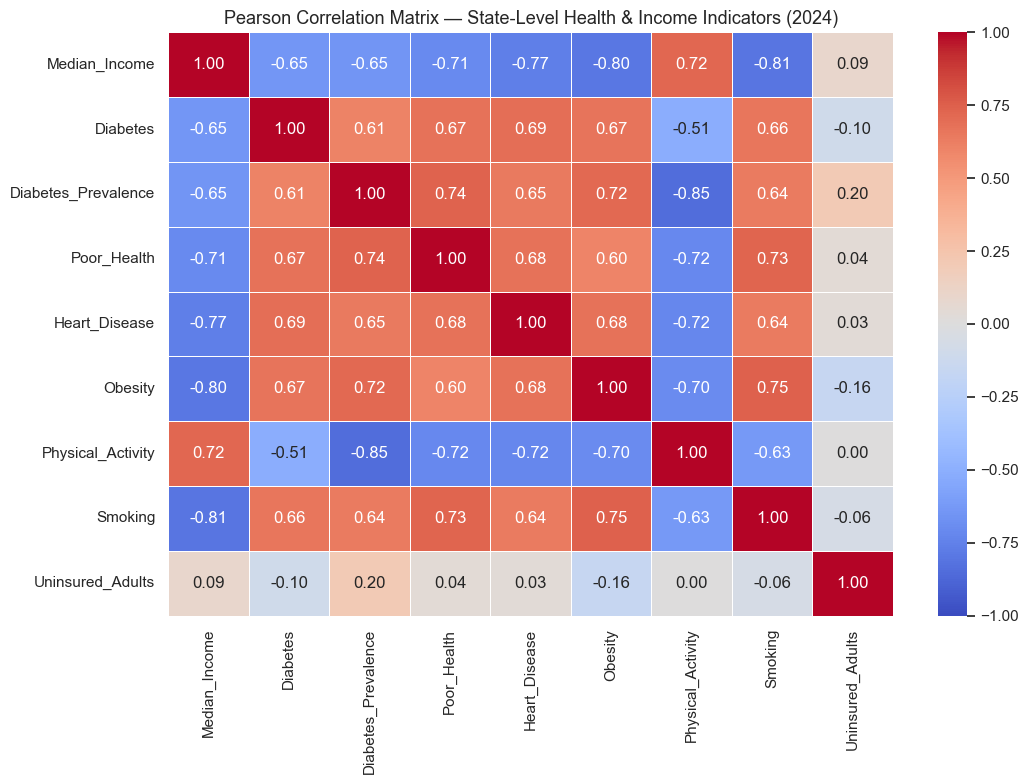

In [79]:
# Compute Pearson correlation matrix (exclude State column)
corr_matrix = eda_df.drop(columns=["State"]).corr()

# Plot heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title("Pearson Correlation Matrix — State-Level Health & Income Indicators (2024)", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap reveals several important patterns relevant to our research question:

- **Strong income–mortality correlation:** `Median_Income` is negatively correlated with both `Heart_Disease` (r = -0.77) and `Diabetes` (r = -0.65), supporting the socioeconomic gradient hypothesis. States with higher median incomes have lower chronic disease mortality rates.

- **Income strongly predicts health behaviors:** `Median_Income` is also strongly negatively correlated with `Smoking` (r = -0.81) and `Obesity` (r = -0.80), and positively correlated with `Physical_Activity` (r = 0.72). This suggests that income may operate partly *through* behavioral channels — a key question for our regression analysis.

- **Health behaviors also predict mortality:** `Smoking`, `Obesity`, and `Poor_Health` all show moderate-to-strong positive correlations with `Heart_Disease` and `Diabetes`. This multicollinearity is expected (richer states also have healthier behaviors) and means we need a multiple regression to isolate income's independent effect.

- **Uninsured rate is a weak predictor:** `Uninsured_Adults` shows near-zero correlations with mortality (r = 0.03 for heart disease), which is surprising. This may be because insurance status at the state level in 2024 reflects policy environments (Medicaid expansion) more than individual access, and this effect washes out at the state aggregate level.

**Takeaway for research question:** The strong income correlations with both mortality and health behaviors motivate the regression analysis below, where we will attempt to separate income's direct effect from its indirect effect through behavior.

### EDA 3: Visualizing the Income–Mortality Gradient

**Why:** The correlation matrix shows the *strength* of income–mortality relationships numerically, but a scatter plot reveals the *shape* of the relationship, the presence of outliers, and whether the relationship is approximately linear. We plot both mortality outcomes (heart disease and diabetes) against income.

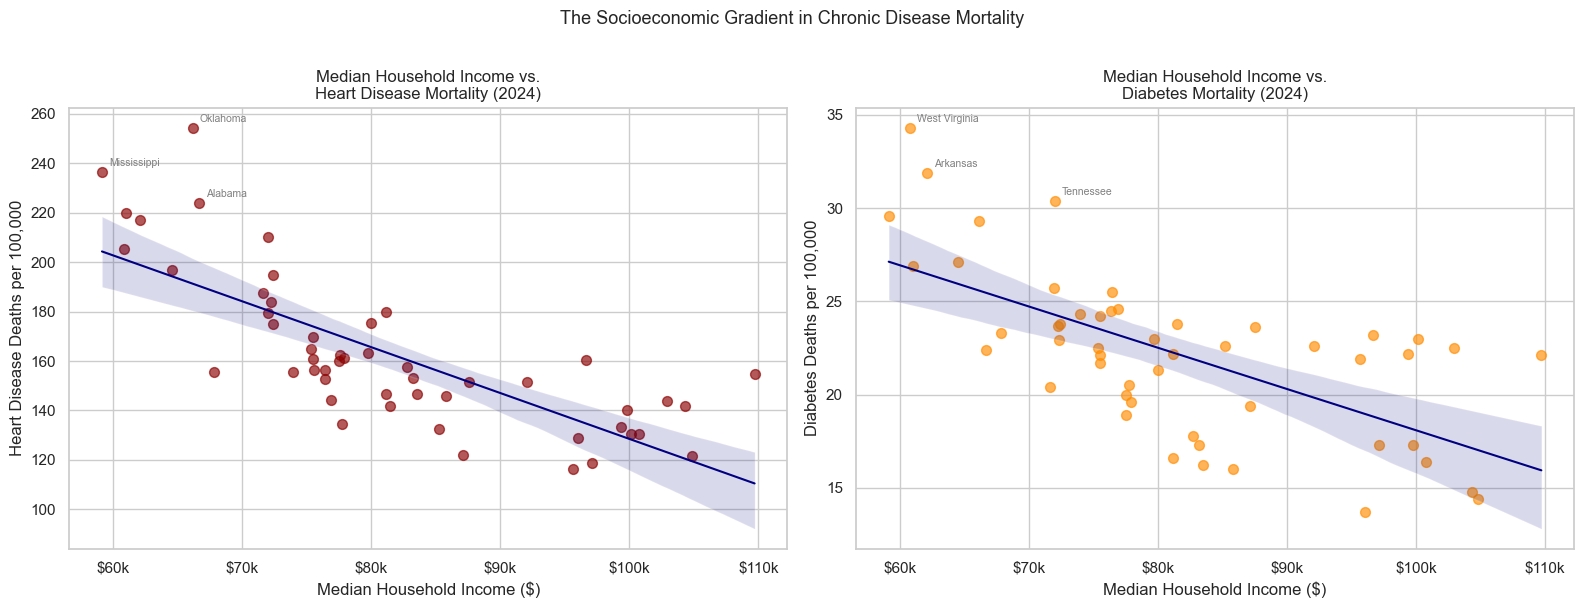

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel A: Median Income vs. Heart Disease Mortality ---
sns.regplot(
    data=eda_df, x="Median_Income", y="Heart_Disease", ax=axes[0],
    scatter_kws={'alpha': 0.65, 'color': 'darkred', 's': 50},
    line_kws={'color': 'navy', 'linewidth': 1.5}
)
# Label a few outliers for context
for _, row in eda_df.nlargest(3, "Heart_Disease").iterrows():
    axes[0].annotate(row["State"], (row["Median_Income"], row["Heart_Disease"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7.5, color="gray")
axes[0].set_title("Median Household Income vs.\nHeart Disease Mortality (2024)", fontsize=12)
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Heart Disease Deaths per 100,000")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

# --- Panel B: Median Income vs. Diabetes Mortality ---
sns.regplot(
    data=eda_df, x="Median_Income", y="Diabetes", ax=axes[1],
    scatter_kws={'alpha': 0.65, 'color': 'darkorange', 's': 50},
    line_kws={'color': 'navy', 'linewidth': 1.5}
)
for _, row in eda_df.nlargest(3, "Diabetes").iterrows():
    axes[1].annotate(row["State"], (row["Median_Income"], row["Diabetes"]),
                     textcoords="offset points", xytext=(5, 4), fontsize=7.5, color="gray")
axes[1].set_title("Median Household Income vs.\nDiabetes Mortality (2024)", fontsize=12)
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Diabetes Deaths per 100,000")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))

plt.suptitle("The Socioeconomic Gradient in Chronic Disease Mortality", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** Both panels show a clear downward-sloping relationship consistent with the socioeconomic gradient hypothesis:

- **Heart Disease (left panel):** As median income increases, heart disease mortality decreases in an approximately linear fashion. The regression line has a steep slope, and the relationship is tight — most states fall close to the trend line. Oklahoma, Mississippi, and Alabama are notable outliers with disproportionately high mortality even given their income levels, suggesting additional regional factors (e.g., diet, rural access to care).

- **Diabetes (right panel):** The same downward gradient holds for diabetes mortality. The relationship appears slightly steeper and noisier than heart disease. West Virginia stands out as an extreme outlier — the highest diabetes death rate in the dataset despite having one of the lowest median incomes, consistent with its well-documented health challenges.

**Implication:** These plots confirm that the income–mortality gradient is not driven by one or two outliers but is a consistent pattern across all income levels. However, the scatter around the regression line suggests that other variables help explain the variation, which we address with regression in EDA 4.

### EDA 4: Geographic Distribution: The "Where" of the Socioeconomic Gradient

**Why we perform this analysis:**
While scatter plots show the correlation between variables, they ignore *geography*. Health outcomes and wealth in the United States are not randomly scattered; they often follow distinct regional patterns. To better understand these regional disparities, we will plot both `Median_Income` and `Heart_Disease` mortality on a US map. Identifying spatial clusters can provide deeper context to our regression results.

In [81]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "-q"])
# Import plotly for interactive maps
import plotly.express as px

# Dictionary to map full state names to 2-letter abbreviations required by plotly
us_state_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

# Add state abbreviations to our dataframe
eda_df['State_Abbrev'] = eda_df['State'].map(us_state_to_abbrev)

# Map 1: Heart Disease Mortality Rate
fig1 = px.choropleth(
    eda_df, 
    locations='State_Abbrev', 
    locationmode="USA-states", 
    color='Heart_Disease',
    scope="usa",
    color_continuous_scale="Reds", 
    title="Heart Disease Mortality Rate by State (2024)",
    labels={'Heart_Disease': 'Deaths per 100k'}
)
fig1.show()

# Map 2: Median Household Income
fig2 = px.choropleth(
    eda_df, 
    locations='State_Abbrev', 
    locationmode="USA-states", 
    color='Median_Income',
    scope="usa",
    color_continuous_scale="Greens", 
    title="Median Household Income by State (2024)",
    labels={'Median_Income': 'Income ($)'}
)
fig2.show()

**Interpretation of Results:**
The two geographic heatmaps provide a powerful visual validation of our regression findings, demonstrating that the socioeconomic gradient has a profound spatial footprint across the United States:

* **The Geographic Mirror Effect:** The two maps act as near-perfect inverse images of one another. Regions that are shaded in the lightest green on the income map (indicating the lowest median wealth) are almost identically shaded in the darkest red on the mortality map (indicating the highest heart disease death rates). 
* **Regional Clustering (The Southern Disadvantage):** We can observe a distinct concentration of severe health and economic disparities in the Deep South and parts of Appalachia/Midwest. States like Arkansas, Oklahoma, Alabama, and Mississippi exhibit the lowest median household incomes alongside the highest heart disease mortality rates (often exceeding 200 deaths per 100,000). 
* **The Coastal / Mountain Advantage:** Conversely, states along the West Coast (e.g., California, Washington), the Northeast corridor (e.g., Massachusetts, New York), and certain Mountain West states (like Colorado) display the opposite trend: high median incomes (dark green) coupled with significantly lower heart disease mortality (light red).
* **Connection to Research Question:** This spatial clustering reinforces our core hypothesis. The socioeconomic gradient is not just an abstract statistical artifact found in a regression table; it represents deeply entrenched regional inequalities. The visual overlap clearly illustrates that a state's macroeconomic environment is inextricably linked to the cardiovascular health of its population.

**Interpretation:**

The descriptive analysis reveals a striking partisan health divide. Blue states have a substantially higher average median income (\$92,322 vs \$74,465) and markedly lower mortality: heart disease averages 140.8 per 100k in blue states versus 177.1 in red states, and diabetes mortality is 19.4 vs 24.0. Red states also show higher obesity (0.36 vs 0.31) and smoking rates (0.13 vs 0.10). The scatter plots confirm that red states disproportionately cluster in the low-income, high-mortality quadrant.

However, the regression tells a different story. After controlling for Log_Income, Obesity, Smoking, and Physical_Activity, the `Red_Dummy` coefficient is just 6.27 for heart disease (p = 0.411) and 0.32 for diabetes (p = 0.807) — neither is statistically significant. The R² values (0.680 and 0.521) barely change compared to the base model. This indicates that the red–blue health gap is **not an independent political effect**, but is almost entirely **mediated through** the income and behavioral risk factor differences between red and blue states. In other words, red states have worse health outcomes primarily because they are poorer and have higher rates of obesity and smoking, not because of political orientation per se.

*** 
## Conclusion

- We find strong evidence of a **socioeconomic gradient in health outcomes**, where higher-income states consistently exhibit lower rates of heart disease and diabetes mortality  

- The negative relationship between income and mortality remains **statistically significant even after controlling for behavioral factors**, indicating that income has an independent effect on health outcomes  

- Behavioral variables such as **smoking, obesity, and physical activity** are also significant predictors of mortality, suggesting that part of the income effect operates through health-related behaviors  

- However, the persistence of the income coefficient after including controls indicates that **income influences health both directly and indirectly**  

- Geographic analysis further shows that **low-income, high-mortality states are regionally clustered**, particularly in the Southern United States, highlighting broader structural and environmental factors  

- Overall, our findings suggest that improving health outcomes requires not only targeting individual behaviors but also addressing **underlying socioeconomic disparities**

---
## Limitations

**1. Small sample size (n = 51).** Our analysis is restricted to 51 state-level observations. This limits statistical power, makes regression coefficients sensitive to outliers, and prevents us from studying within-state variation (e.g., rural vs. urban differences). The TA noted that ZIP-code level data would enable a more fine-grained analysis; we were unable to find 2024 data at that resolution for all variables, so state-level analysis is our approach.

**2. Cross-sectional design.** Because we use a single year (2024), we cannot make causal claims about the direction of the income–health relationship. States with historically poor health outcomes may attract less investment and have lower incomes as a result (reverse causality), or both may be driven by a third factor (omitted variable bias).

**3. Mean imputation for Tennessee missing values.** Tennessee's values for `Diabetes_Prevalence`, `Poor_Health`, `Physical_Activity`, `Smoking`, and `Obesity` were suppressed in the KFF source data (small BRFSS survey sample). We imputed these five cells with column means to preserve Tennessee as an observation. Tennessee's imputed behavioral values may not accurately reflect its true profile — this is particularly relevant for analyses involving smoking or obesity.

**4. Missing socioeconomic controls.** Education, employment, and poverty datasets were initially explored but were incompatible with state-level aggregation. Including education attainment or poverty rates as additional controls could improve the regression models and reduce omitted variable bias.

**5. Ecological fallacy.** All variables are state-level aggregates. Relationships observed at the state level may not hold at the individual level (e.g., not every low-income individual in a low-income state has poor health outcomes). Our conclusions apply to states as units, not individuals.

**6. Multicollinearity.** Income, smoking, and obesity are strongly correlated with each other (r > 0.80). This makes it difficult to isolate the independent contribution of each variable in regression models, and may inflate standard errors on the behavioral covariates.

***
## Acknowledgements and Bibliography

- U.S. Census Bureau. *American Community Survey (ACS) 2024 1-Year Estimates.*  

  https://www.census.gov/programs-surveys/acs  

- Kaiser Family Foundation (KFF). *State Health Facts (2024).*  

  https://www.kff.org/statedata/  

- Statsmodels Developers. *Statsmodels: Statistical Modeling in Python.*  

  https://www.statsmodels.org/  

- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment.* Computing in Science & Engineering, 9(3), 90–95.  

- Waskom, M. (2021). *Seaborn: Statistical Data Visualization.* Journal of Open Source Software.  

- Plotly Technologies Inc. *Plotly: Interactive Data Visualization Library.*  

  https://plotly.com/python/  

- Project GitHub Repository:  

  https://github.com/MarinaCui/Data-Science-in-the-Wild-Final-Project  